# 04 · Regularization — Code

We deliberately overfit a small network on a small, noisy dataset, then apply each regularization technique one at a time and watch the train/validation gap shrink.

Part A: NumPy from scratch (L1/L2 penalty, Dropout, Batch Norm, early stopping, augmentation).
Part B: the PyTorch equivalent (`weight_decay`, `nn.Dropout`, `nn.BatchNorm1d`).

# Part A — NumPy From Scratch

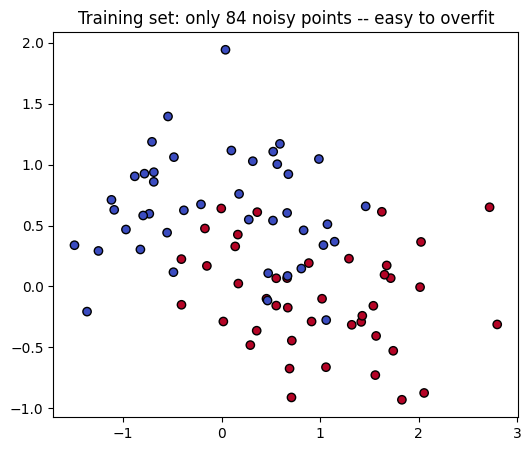

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Small, noisy dataset with FEW samples -- deliberately easy to overfit
X, y = make_moons(n_samples=120, noise=0.35, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)
y_train = y_train.reshape(-1, 1); y_val = y_val.reshape(-1, 1)

def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def relu(z): return np.maximum(0, z)
def relu_derivative(z): return (z > 0).astype(float)
def bce(y_true, y_pred, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))

plt.figure(figsize=(6,5))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train.ravel(), cmap='coolwarm', edgecolors='k')
plt.title(f"Training set: only {len(X_train)} noisy points -- easy to overfit")
plt.show()

## A wide, unregularized network (deliberately prone to overfitting)

In [2]:
class RegNet:
    """A configurable network supporting L1/L2 penalty and Dropout."""
    def __init__(self, input_dim=2, hidden_dim=64, output_dim=1, lr=0.1,
                 l1=0.0, l2=0.0, dropout_p=0.0):
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0/input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0/hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        self.lr = lr
        self.l1 = l1
        self.l2 = l2
        self.dropout_p = dropout_p

    def forward(self, X, training=True):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)

        # ---- Dropout: randomly zero neurons during TRAINING only ----
        if training and self.dropout_p > 0:
            self.dropout_mask = (np.random.rand(*self.a1.shape) > self.dropout_p) / (1 - self.dropout_p)
            self.a1 = self.a1 * self.dropout_mask
        else:
            self.dropout_mask = np.ones_like(self.a1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        n = X.shape[0]
        dz2 = (self.a2 - y) / n
        dW2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = (dz2 @ self.W2.T) * self.dropout_mask   # dropout mask applied in backward too
        dz1 = da1 * relu_derivative(self.z1)
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # ---- L1 / L2 regularization gradients, added on top of the normal gradient ----
        dW2 += self.l2 * 2 * self.W2 + self.l1 * np.sign(self.W2)
        dW1 += self.l2 * 2 * self.W1 + self.l1 * np.sign(self.W1)

        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1

    def penalty(self):
        l1_term = self.l1 * (np.sum(np.abs(self.W1)) + np.sum(np.abs(self.W2)))
        l2_term = self.l2 * (np.sum(self.W1**2) + np.sum(self.W2**2))
        return l1_term + l2_term

def train_and_track(net, X_train, y_train, X_val, y_val, epochs=800):
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        y_pred = net.forward(X_train, training=True)
        net.backward(X_train, y_train)
        train_losses.append(bce(y_train, y_pred) + net.penalty())
        val_pred = net.forward(X_val, training=False)   # no dropout at eval time
        val_losses.append(bce(y_val, val_pred))
    return train_losses, val_losses

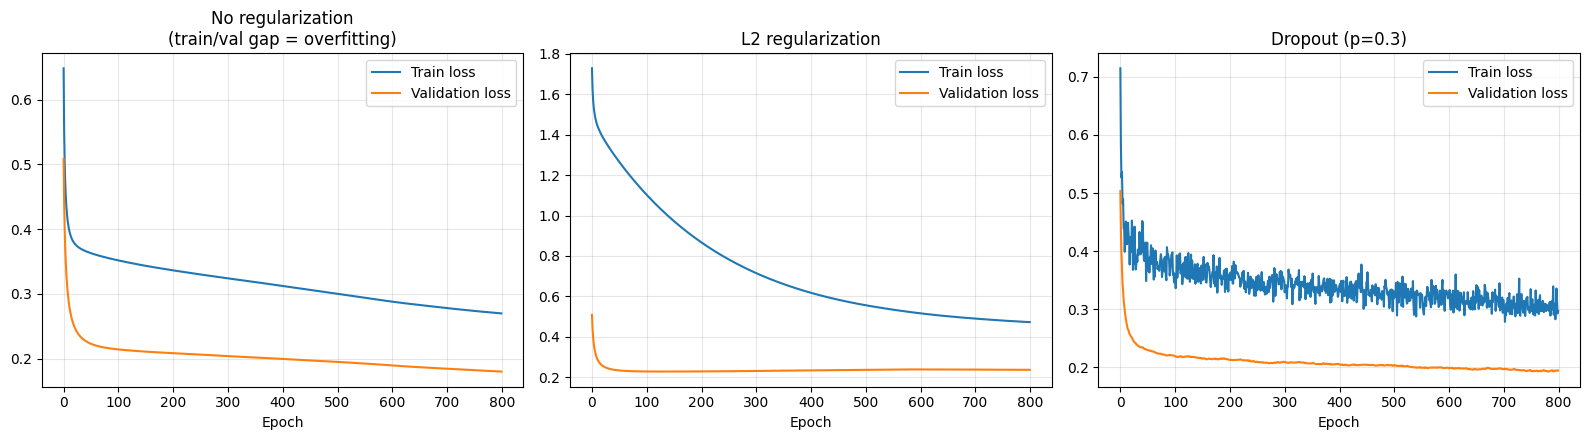

Look at the GAP between train and validation loss in each plot:
the unregularized net's gap widens over time (overfitting); L2/Dropout keep it tighter.


In [3]:
np.random.seed(1)
net_plain = RegNet(hidden_dim=64, lr=0.1)  # no regularization at all
train_plain, val_plain = train_and_track(net_plain, X_train, y_train, X_val, y_val)

np.random.seed(1)
net_l2 = RegNet(hidden_dim=64, lr=0.1, l2=0.01)  # L2 regularization
train_l2, val_l2 = train_and_track(net_l2, X_train, y_train, X_val, y_val)

np.random.seed(1)
net_dropout = RegNet(hidden_dim=64, lr=0.1, dropout_p=0.3)  # Dropout
train_drop, val_drop = train_and_track(net_dropout, X_train, y_train, X_val, y_val)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (tr, va, title) in zip(axes, [
        (train_plain, val_plain, "No regularization\n(train/val gap = overfitting)"),
        (train_l2, val_l2, "L2 regularization"),
        (train_drop, val_drop, "Dropout (p=0.3)")]):
    ax.plot(tr, label='Train loss')
    ax.plot(va, label='Validation loss')
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Look at the GAP between train and validation loss in each plot:")
print("the unregularized net's gap widens over time (overfitting); L2/Dropout keep it tighter.")

## Early Stopping

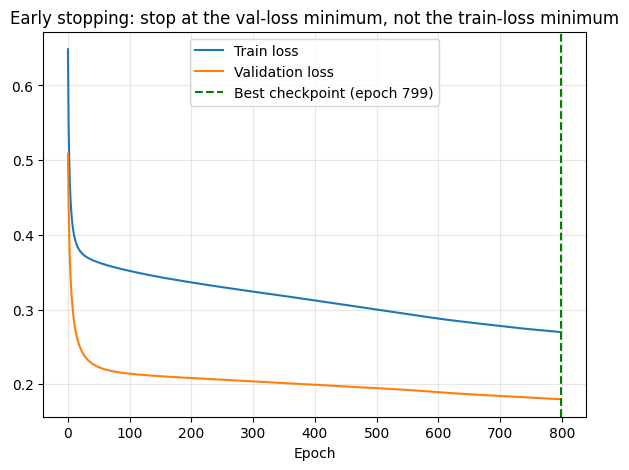

In [4]:
def train_with_early_stopping(net, X_train, y_train, X_val, y_val, max_epochs=800, patience=30):
    best_val_loss = np.inf
    best_weights = None
    epochs_without_improvement = 0
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        y_pred = net.forward(X_train, training=True)
        net.backward(X_train, y_train)
        train_losses.append(bce(y_train, y_pred))

        val_pred = net.forward(X_val, training=False)
        val_loss = bce(y_val, val_pred)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = (net.W1.copy(), net.b1.copy(), net.W2.copy(), net.b2.copy())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch} (best val loss {best_val_loss:.4f} at epoch {epoch - patience})")
            net.W1, net.b1, net.W2, net.b2 = best_weights   # restore best checkpoint
            break

    return train_losses, val_losses

np.random.seed(1)
net_es = RegNet(hidden_dim=64, lr=0.1)
train_es, val_es = train_with_early_stopping(net_es, X_train, y_train, X_val, y_val, patience=30)

plt.figure(figsize=(7,5))
plt.plot(train_es, label='Train loss')
plt.plot(val_es, label='Validation loss')
best_epoch = int(np.argmin(val_es))
plt.axvline(best_epoch, color='green', linestyle='--', label=f'Best checkpoint (epoch {best_epoch})')
plt.title("Early stopping: stop at the val-loss minimum, not the train-loss minimum")
plt.xlabel("Epoch"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Data Augmentation (manual, for 2D points)

Original training set: 84 points -> Augmented: 384 points


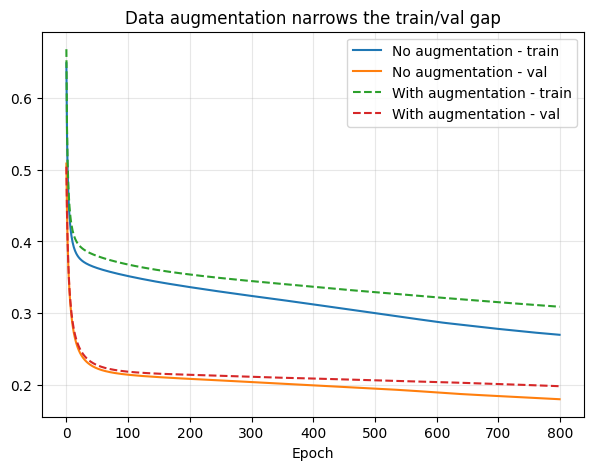

In [5]:
def augment(X, y, n_augmented=200, noise_std=0.15):
    """Simple augmentation: duplicate points with added Gaussian jitter (a 2D analogue
    of image random-crop/flip -- same idea, label-preserving small perturbations)."""
    idx = np.random.randint(0, len(X), size=n_augmented)
    X_aug = X[idx] + np.random.normal(0, noise_std, size=(n_augmented, X.shape[1]))
    y_aug = y[idx]
    return np.vstack([X, X_aug]), np.vstack([y, y_aug])

X_train_aug, y_train_aug = augment(X_train, y_train, n_augmented=300)
print(f"Original training set: {len(X_train)} points -> Augmented: {len(X_train_aug)} points")

np.random.seed(1)
net_aug = RegNet(hidden_dim=64, lr=0.1)
train_aug, val_aug = train_and_track(net_aug, X_train_aug, y_train_aug, X_val, y_val)

plt.figure(figsize=(7,5))
plt.plot(train_plain, label='No augmentation - train')
plt.plot(val_plain, label='No augmentation - val')
plt.plot(train_aug, label='With augmentation - train', linestyle='--')
plt.plot(val_aug, label='With augmentation - val', linestyle='--')
plt.title("Data augmentation narrows the train/val gap")
plt.xlabel("Epoch"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Batch Normalization (from scratch, simplified)

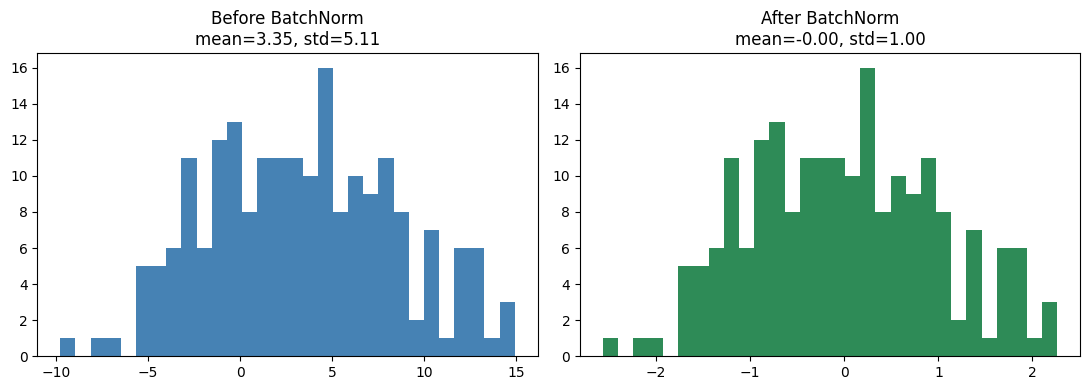

BatchNorm re-centers and re-scales activations every layer, every batch --
keeping the distribution stable throughout training regardless of how earlier weights shift.


In [6]:
def batchnorm_forward(z, gamma, beta, eps=1e-5):
    """Simplified batch norm forward pass (training mode: uses batch statistics)."""
    mu = np.mean(z, axis=0, keepdims=True)
    var = np.var(z, axis=0, keepdims=True)
    z_hat = (z - mu) / np.sqrt(var + eps)
    out = gamma * z_hat + beta
    return out, z_hat, mu, var

# Demo: show how batch norm reshapes a layer's raw pre-activation distribution
np.random.seed(0)
z_raw = np.random.randn(200, 1) * 5 + 3   # activations with large scale & nonzero mean, mimicking an
                                             # untrained layer's poorly-scaled output
gamma, beta = np.array([1.0]), np.array([0.0])
z_normed, _, mu, var = batchnorm_forward(z_raw, gamma, beta)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(z_raw.ravel(), bins=30, color='steelblue')
axes[0].set_title(f"Before BatchNorm\nmean={z_raw.mean():.2f}, std={z_raw.std():.2f}")
axes[1].hist(z_normed.ravel(), bins=30, color='seagreen')
axes[1].set_title(f"After BatchNorm\nmean={z_normed.mean():.2f}, std={z_normed.std():.2f}")
plt.tight_layout()
plt.show()

print("BatchNorm re-centers and re-scales activations every layer, every batch --")
print("keeping the distribution stable throughout training regardless of how earlier weights shift.")

---
# Part B — PyTorch Equivalent

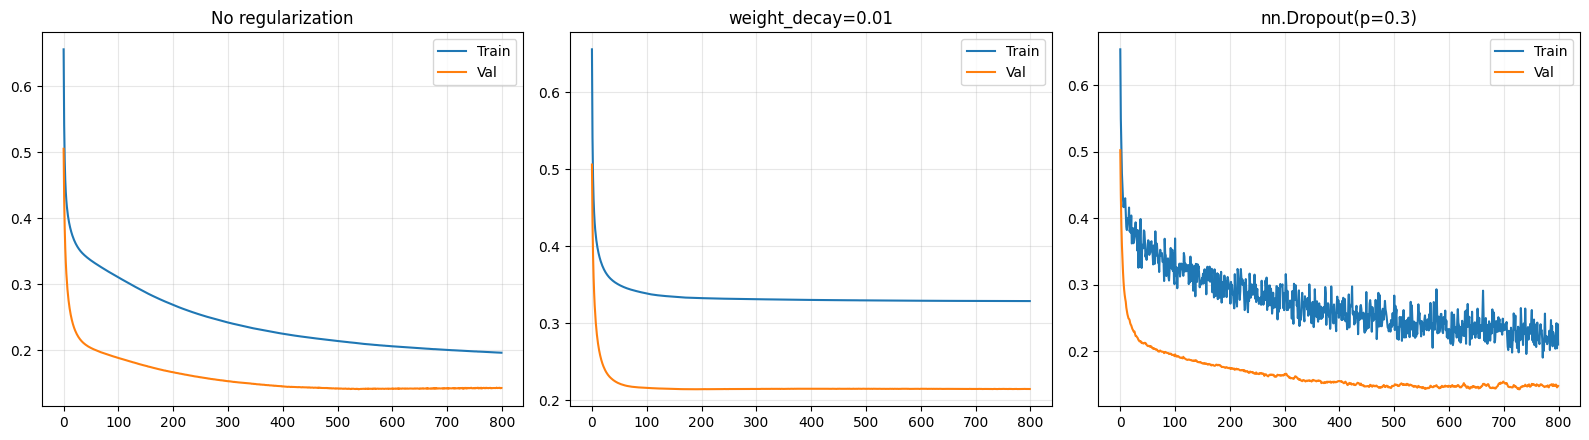

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(1)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

class TorchRegNet(nn.Module):
    def __init__(self, hidden_dim=64, dropout_p=0.0, use_bn=False):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim) if use_bn else nn.Identity()  # <-- BatchNorm
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_p)                                # <-- Dropout
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        return self.sigmoid(self.fc2(x))

def train_torch(model, weight_decay=0.0, epochs=800):
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.5, weight_decay=weight_decay)  # <-- L2 / weight decay
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()                      # <-- enables Dropout / BatchNorm training-mode behavior
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward(); optimizer.step()
        train_losses.append(loss.item())

        model.eval()                        # <-- disables Dropout, uses running BatchNorm stats
        with torch.no_grad():
            val_losses.append(criterion(model(X_val_t), y_val_t).item())
    return train_losses, val_losses

torch.manual_seed(1); model_plain = TorchRegNet()
tr_plain_t, va_plain_t = train_torch(model_plain)

torch.manual_seed(1); model_wd = TorchRegNet()
tr_wd_t, va_wd_t = train_torch(model_wd, weight_decay=0.01)

torch.manual_seed(1); model_drop = TorchRegNet(dropout_p=0.3)
tr_drop_t, va_drop_t = train_torch(model_drop)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (tr, va, title) in zip(axes, [
        (tr_plain_t, va_plain_t, "No regularization"),
        (tr_wd_t, va_wd_t, "weight_decay=0.01"),
        (tr_drop_t, va_drop_t, "nn.Dropout(p=0.3)")]):
    ax.plot(tr, label='Train'); ax.plot(va, label='Val')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()